In [55]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import sklearn
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from google.colab import drive
import json
import os


Introduzione
L'obiettivo principale di questo progetto è lo sviluppo di un modello di Natural Language Processing (NLP) capace di stimare il grado di stereotipicità presente in un commento testuale. A differenza della classica classificazione binaria (dove un testo è etichettato semplicemente come "stereotipato" o "non stereotipato"), questo task è configurato come un problema di regressione.

In [56]:
####### CARICAMENTO DATASET #########
# Percorso aggiornato basato sulla tua indicazione
path_dataset = "/kaggle/input/datasets/laurazangh/dataset-finaleeee"
path_file = os.path.join(path_dataset, "gsi-d_DEV.jsonl") 

lista_frasi = []

# 2. CARICAMENTO DATI
if os.path.exists(path_file):
    with open(path_file, "r", encoding="utf-8") as f:
        for line in f:
            riga = json.loads(line)
            lista_frasi.append(riga)
    
    df_originale = pd.DataFrame(lista_frasi)
    print(f"Caricate {len(lista_frasi)} frasi con successo!")
else:
    print(f"Errore: Il file non è stato trovato in {path_file}")
    # Utility per debug: stampa l'albero dei file per trovare il percorso esatto
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if file.endswith(".jsonl"):
                print(f"File trovato qui: {os.path.join(root, file)}")

Caricate 200 frasi con successo!


**1. PRE-PROCESSING**
Ecco le regole che abbiamo seguito per fare pre-processing nel nostro task:
-Trasformazione delle emoji in descrizione testuale sia del testo che del contesto
-No lemming principalmente per due motivi: 1. in un compito di genere è essenziale che pronomi/aggettivi/articoli restino femminili, 2.è importante che pronomi/aggettivi/parole restino al plurale come indizio di stereotipicità
-No stop words removal perchè andrebbe a rimuovere elementi come "non", "tutte" che sono essenziali per il significato della frase. Per esempio se ho "le donne non sanno guidare" e rimuovo NON, il significato della frase diventa l'oppposto rispetto a quello reale.
-No rimozione punteggiatura perchè fornisce info rilevanti
-No trasformazione parole in minuscolo perchè nel contesto dei commenti le parole in maiuscolo possono rappresentare rabbia del commentatore, importanza data a una parola specifica e in generale
possono essere sfruttati per fare sentiment analisys
-No rimozione del contesto pensando che il solo commento basti perchè è stato introdotto proprio per spiegare il commento; in particolare abbiamo notato ad esempio un commento "Affidabilissima"
e ovviamente senza avere altre info ,potrebbe essere sarcastico (nel senso che i piloti sono nella maggior parte dei casi uomini e quindi una donna non può pilotare un aereo)
oppure no, per cui il modello avrebbe problemi a capirlo senza contestualizzazione. In particolare abbiamo suddiviso il commento in due, separando il contesto dal testo (sarà spiegato meglio in seguito)


In [57]:
import re
import emoji

######## PRE-PROCESSING ##########

def preprocess_text(text):
    if not text:
        return ""

    #Converte emoji in descrizione testuale (es. 😂 -> :faccina_che_ride)
    text = emoji.demojize(text, language='it')

    #Sostituzione di spazi, tab, ritorni a capo con un solo spazio
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for riga in lista_frasi:
    riga['text'] = preprocess_text(riga.get('text', ''))




In [58]:
# Qui abbiamo preparato i dati grezzi all'addestramento ossia convertito i giudizi testuali ("yes"/"no") in 
# valori binari (1/0), l'informazione sulla presenza del  contesto in un formato numerico (1 per 'with_context',
# 0 per 'no_context'), le annotazioni sono già numeriche.

def converti_annot_e_contesto(lista_frasi):
    for frase in lista_frasi:
        for i, val in enumerate(frase["annotations"]):
            if val == "yes":
                frase["annotations"][i] = 1
            elif val == "no":
                frase["annotations"][i] = 0

        # conversione context
        if frase.get('context') == 'with_context':
            frase['context'] = 1
        elif frase.get('context') == 'no_context':
            frase['context'] = 0

    return lista_frasi

converti_annot_e_contesto(lista_frasi)

[{'id': 'GS0458',
  'text': '[Commento a una vecchia foto di un matrimonio in cui sia gli sposi, sia gli invitati sono tutti molto seri, con la dicitura "Un matrimonio d\'altri tempi :cuore_rosso:"] IO, mammta e tu, non ne posso più ecc ecc ecc. Dobbiamo anche dire, che i matrimoni duravano una vita e non si sentivano tutti i giorni come oggi di femminicidi, si scherza MOLTO sui sentimenti delle persone, perche\' la torta viene mangiata prima della festa e datosi che non c\'è più vergogna di NIENTE, molto facilmente si dice che non era buona e non c\'è più desiderio, ma sé si mangia un poco alla volta, la torta è desiderata e buona, poche parole a buon intenditore!',
  'annotations': [0, 0, 1, 0],
  'gs_value': '0.25',
  'gs_category': 'sexual',
  'context': 1},
 {'id': 'GS0414',
  'text': "per i lavori che hai citato, se si presentano un uomo e una donna, assumeranno l'uomo. Per questo quei lavori sono a netta prevalenza maschile. A meno che una non abbia la propria attività nell'edil

In [ ]:
# separazione contesto con contatore, solo contesto_frase
def separa_contesto(lista_frasi):
    for riga in lista_frasi:
        text = riga.get('text', '')

        # se non inizia con '[', niente contesto
        if not text.strip().startswith('['):
            riga['contesto_frase'] = ''
            riga['text'] = preprocess_text(text)
            continue

        count = 0
        split_idx = -1

        # loop con contatore per quadre annidate
        for i, char in enumerate(text):
            if char == '[':
                count += 1
            elif char == ']':
                count -= 1
                if count == 0:
                    split_idx = i
                    break

        if split_idx != -1:
            contesto = text[1:split_idx].strip()
            testo = text[split_idx + 1:].strip()

            riga['contesto_frase'] = contesto if contesto else ''
            riga['text'] = preprocess_text(testo) if testo else "testo vuoto"
        else:
            riga['contesto_frase'] = ''
            riga['text'] = preprocess_text(text) if text else "testo vuoto"

    return lista_frasi

# --- Esecuzione pipeline ---
lista_frasi = converti_annot_e_contesto(lista_frasi)
lista_frasi = separa_contesto(lista_frasi)

# --- Trasformazione in DataFrame ---
df = pd.DataFrame(lista_frasi)
# salva tutto il DataFrame in CSV
df.to_csv("tutte_frasi.csv", index=False, encoding='utf-8-sig')
df2 = pd.read_csv("tutte_frasi.csv")
df2.head()

**2. SEPARAZIONE TESTO E CONTESTO**
Inizialmente, il testo e il contesto venivano passati al modello come un'unica stringa indifferenziata (es: "[Contesto] Commento"). 
Abbiamo tuttavia pensato che il modello potesse interpretare i segni di punteggiatura (punti, punti e virgola) come confini sintattici naturali,
frammentando il commento e confondendo la reale opinione dell'utente con il materiale di supporto ossia il contesto.
Poiché i modelli basati su BERT sono pre-addestrati per riconoscere il punto fermo come fine di un'unità semantica, il rischio era una 
contaminazione tra contesto e testo. Abbiamo quindi implementato una separazione esplicita dei due segmenti, permettendo al modello di inserire 
nativamente il token speciale tra di essi. Questo forza il meccanismo di Self-Attention a distinguere i due ruoli semantici, migliorando la precisione 
nell'assegnazione dello stereotipo.

In [59]:
# Qui viene effettivamente fatto parsing tenendo conto del fatto che il contesto è isolato dalle quadre
# Viene identificato il blocco racchiuso tra '[' e ']'gestendo correttamente eventuali parentesi annidate tramite un contatore.
# In particolare la normalizzazione tramite la funzione 'preprocess_text' è stata fatta prima di divedere
# testo da contesto. Allora alla fine: 
# - 'contesto_frase': Contiene la spiegazione del commento
#  - 'text': Contiene adesso il solo commento dell'utente

def separa_contesto(lista_frasi):
    for riga in lista_frasi:
        # se contesto già estratto, salta la riga
        if riga.get('contesto_frase', '').strip() != '':
            continue

        text = riga.get('text', '')

        count = 0
        split_idx = -1
        start_idx = text.find('[')  # cerca primo '['

        # se non ci sono quadre, niente contesto
        if start_idx == -1:
            riga['contesto_frase'] = ''  # vuoto se non c'è contesto
            riga['text'] = preprocess_text(text)
            continue

        # loop con contatore per quadre annidate
        for i, char in enumerate(text[start_idx:], start=start_idx):
            if char == '[':
                count += 1
            elif char == ']':
                count -= 1
                if count == 0:
                    split_idx = i
                    break

        if split_idx != -1:
            # estrai contesto e testo principale
            contesto = text[start_idx+1:split_idx].strip()
            testo = text[:start_idx].strip() + ' ' + text[split_idx+1:].strip()
            
            riga['contesto_frase'] = contesto
            riga['text'] = preprocess_text(testo)
        else:
            # quadre non chiuse correttamente → niente contesto
            riga['contesto_frase'] = ''
            riga['text'] = preprocess_text(text)

    return lista_frasi
    

lista_frasi = separa_contesto(lista_frasi)

# crea DataFrame
import pandas as pd
df = pd.DataFrame(lista_frasi)

# salva tutto in CSV
df.to_csv("tutte_frasi.csv", index=False, encoding='utf-8-sig')
df_con_contesto = df[df['contesto_frase'].apply(lambda x: isinstance(x, str) and x.strip() != '')]
print(df_con_contesto)
print(f"Il DataFrame adesso ha {df_con_contesto.shape[1]} colonne.")


         id                                               text   annotations  \
0    GS0458  IO, mammta e tu, non ne posso più ecc ecc ecc....  [0, 0, 1, 0]   
4    GS0719  Magari gli stessi bulli piangevano dietro la s...  [0, 0, 0, 0]   
5    GS0175  Per fare la magistrata dovevi studiare,non scu...  [1, 1, 1, 1]   
8    GS0583  Due titanidi!!…sarà una finale con senza esclu...  [0, 0, 0, 1]   
13   GS0610  È giunti il momento che vi fermiate per una lu...  [0, 0, 0, 0]   
..      ...                                                ...           ...   
189  GS0867  Uno di programmi/concorsi più no sense che esi...  [0, 0, 1, 1]   
190  GS0872  trovo abominevole che ci siano ancora donne ch...  [0, 0, 1, 0]   
194  GS0897  Patetica, ignorante, burattina, ridicola, ingu...  [0, 0, 1, 1]   
196  GS0921  Vorrei tantissimo una femminuccia xké ho tre b...  [0, 0, 0, 1]   
197  GS0944             Ma vi siete sposate o fate le schiave?  [1, 0, 1, 0]   

    gs_value gs_category  context  \
0 

**3. SCELTA MODELLO**
Dopo aver completato l'addestramento e la validazione tramite Cross-Validation su entrambi i modelli, abbiamo effettuato un'analisi comparativa 
tra BERT (dbmdz/bert-base-italian-cased) e Umberto (Musixmatch/umberto-commoncrawl-cased-v1) che si basa sull'architettura RoBERTa.
Sebbene i risultati numerici in termini di MSE (Mean Squared Error) e stabilità della Loss non abbiano mostrato una divergenza drastica, la nostra scelta finale è ricaduta su Umberto per le seguenti ragioni strategiche:
BERT è stato addestrato prevalentemente su Wikipedia e testi letterari. Sebbene eccellente per la lingua italiana standard, può risultare rigido di fronte al linguaggio dei commenti online.
Umberto, essendo basato su un corpus derivato da CommonCrawl, ha una conoscenza nativa del linguaggio "reale" del web, inclusi slang, neologismi e strutture sintattiche tipiche dei social media. 
Abbiamo inoltre notato che essendo commenti di social media, scritti talvolta in modo abbrevviato tipo "xk" per indicare "perchè" o "x smp" per indicare "
per sempre" Bert faceva fativa a ricomporne il senso trattandoli come rumore o errori ortografici,facendo così perdere la carica d'odio o lo stereotipo contenuto, motivo per cui alcune frasi che contenevano
parole abbrevviate venivano sbagliate dal modello nell'attribuzione del gs_value.Abbiamo quindi supposto potesse essere perchè effettivamente non riusciva a ricomporre alcune parole
che avevano grande influenza nella frase. Differentemente UmBERTO talvolta era più capace a gestire quelli che apparentemente possono sembrare errori ma in realtà fanno parte del modo di scrivere nei social. 
Altra cosa importante che ci ha portato a scegliere Umberto rispetto a Bert riguarda la comprensione del sarcasmo della frase perchè Bert tende a prendere le parole in modo più letterale e formale
mentre Umberto è più bravo a percepire il "tono" sarcastico di certe espressioni italiane comuni (come l'uso di "Sì vabbè" a inizio frase). Nonostante l'ottima resa semantica, abbiamo identificato un limite ricorrente: 
Umberto fatica a distinguere tra la negatività lessicale e la stereotipicità reale.
Infatti in presenza di termini espliciti riferiti all'anatomia sessuale oppure parolacce il modello tende a sovrastimare il valore di GSI (Gold Standard Index). 
La forte carica negativa di queste parole "offusca" il senso globale della frase; di conseguenza, commenti che sono semplicemente volgari ma privi di stereotipi contro un gruppo specifico vengono
erroneamente classificati come stereotipati.

In [60]:
import json
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import KFold
from torch.optim import AdamW
import emoji
import matplotlib.pyplot as plt

######## CONFIGURAZIONE IPERPARAMETRI E AMBIENTE ######## 

# In questa sezione definiamo i parametri che guidano l'addestramento e l'architettura.
# La scelta di questi valori è critica per bilanciare precisione, uso di memoria
# e capacità di generalizzazione del modello. 

INPUT_DIR = "/kaggle/input/" 

CONFIG = {
    "model_name": "Musixmatch/umberto-commoncrawl-cased-v1",
    "max_len": 180,
    "batch_size": 8,
    "epochs": 60,
    "patience": 12,
    "n_splits": 5,
    "seed": 42,
    "dataset_path": os.path.join(INPUT_DIR, "datasetprog/gsi-d_DEV.jsonl"), 
    "alpha": 0.7,
    "output_dir": "/kaggle/working/"
}

torch.manual_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")



Dispositivo in uso: cuda


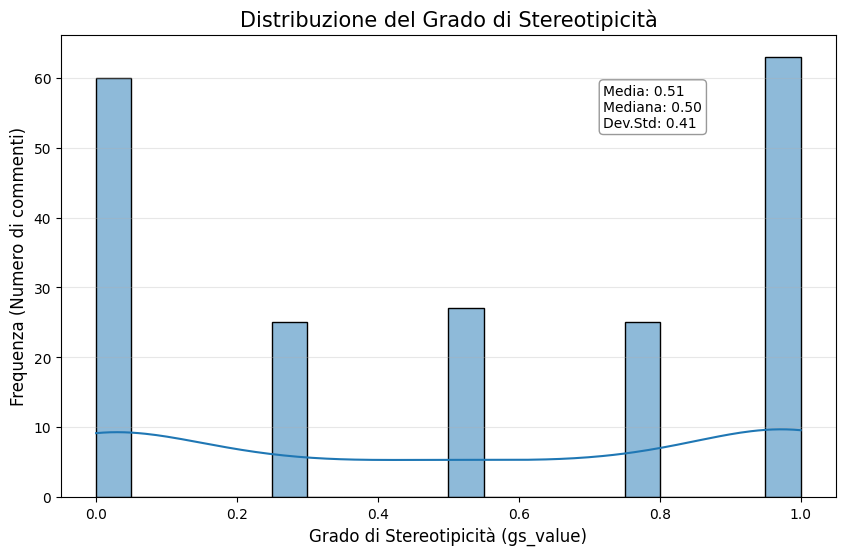

gs_value
0.00    60
0.25    25
0.50    27
0.75    25
1.00    63
Name: count, dtype: int64


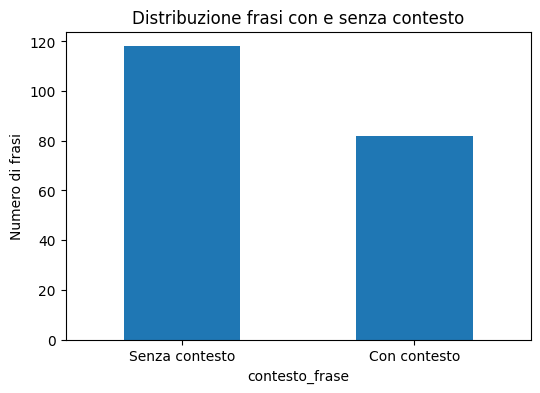

contesto_frase
True     118
False     82
Name: count, dtype: int64


In [61]:
##### CONTROLLO BILANCIAMENTO DATASET
#-----------------------------------------
# Abbiamo pensato di controllare che non ci fosse forte sbilanciamento sia dei valori 'gs', quindi che ci fossero troppe frasi annotate con gs=0, gs=1 o valori intermedi,
#sia dei valori 'context' quindi che non ci fossero troppe frasi con contesto rispetto a quelle senza. Facendo un'analisi abbiamo osservato che fra le 200 frasi date, quelle con gs=0 e gs=1 sono il triplo di quelle con 
#gs intermedi quindi risulta sbilanciato.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 FIX FONDAMENTALE: gs_value deve essere numerico
df['gs_value'] = pd.to_numeric(df['gs_value'], errors='coerce')

def plot_target_distribution(df):
    plt.figure(figsize=(10, 6))

    # Istogramma + KDE
    sns.histplot(
        df['gs_value'].dropna(),
        bins=20,
        kde=True,
        edgecolor='black'
    )

    plt.title('Distribuzione del Grado di Stereotipicità', fontsize=15)
    plt.xlabel('Grado di Stereotipicità (gs_value)', fontsize=12)
    plt.ylabel('Frequenza (Numero di commenti)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Statistiche corrette
    stats = df['gs_value'].dropna().describe()

    plt.annotate(
        f"Media: {stats['mean']:.2f}\n"
        f"Mediana: {stats['50%']:.2f}\n"
        f"Dev.Std: {stats['std']:.2f}",
        xy=(0.70, 0.80),
        xycoords='axes fraction',
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8)
    )

    plt.show()

plot_target_distribution(df)

# Conteggi esatti per valore
print(df['gs_value'].value_counts().sort_index())

# True = con contesto, False = senza contesto
conteggio = (df['contesto_frase'].str.strip() != '').value_counts()

plt.figure(figsize=(6, 4))
conteggio.plot(kind='bar')

plt.xticks(
    [0, 1],
    ['Senza contesto', 'Con contesto'],
    rotation=0
)

plt.ylabel('Numero di frasi')
plt.title('Distribuzione frasi con e senza contesto')
plt.show()
print(conteggio)



**4. Dataset personalizzato per il task GSI**
Gestisce l'input combinato 'Commento + Contesto' e prepara i target per l'architettura Multi-Task:
1. Target Regressivo: il valore medio di stereotipicità (gs_value).
2. Target Ausiliario: le annotazioni (yes/no) per riflettere il disaccordo tra annotatori.
In particolare, gestisce dinamicamente i 'token_type_ids': questi vengono estratti e passati 
quando si utilizza BERT (che li richiede per la segmentazione della frase), 
mentre vengono gestiti come segnaposto neutri per Umberto (basato su RoBERTa), che non utilizza i segment embeddings.

Per quanto riguarda invece il PADDING, avevamo inizialemente fatto padding dinamico per evitare che ci fossero frasi troppo brevi e padding fisso troppo alto per cui il modello andava ad aggiungere troppi 1 inutili. 
In realtà sembrava performare peggio quindi abbiamo usato padding fisso a 180 token che ha stabilizzato la regressione e ridotto l'MSE (abbiamo osservato che la maggior parte delle frasi avevano in media stessa quantità di token
sotto i 200 quindi abbiamo preso un valore limite). Abbiamo invece previsto che il troncamento delle frasi troppo lunghe viene fatto a partire dalla sinistra di inizio contesto così viene rimosso la parte iniziale che non dà
info perchè è tipo un pattern "Commento a..." seguito poi dal titolo mentrele info importanti risiedono nella parte finale di esso. 


In [62]:

class GSIDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): 
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        main_text = str(row['text'])
        # Usa la colonna 'contesto_frase' creata dalla tua funzione di split
        context_text = str(row['contesto_frase']) if row['contesto_frase'] != '' else None

        if not main_text or main_text.isspace():
            main_text = "[vuoto]"

        inputs = self.tokenizer(
            text=main_text,
            text_pair=context_text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation='only_second',
            return_tensors="pt"
        )

        # Calcolo della distribuzione per la aux_head basandoci sulle tue annotazioni (0 e 1)
        annots = row['annotations'] # Questa è la lista di 0 e 1
        count_yes = sum(annots)
        count_no = len(annots) - count_yes
        aux_dist = [count_no / len(annots), count_yes / len(annots)] if len(annots) > 0 else [0.5, 0.5]

        return {
            'ids': inputs['input_ids'].squeeze(0),
            'mask': inputs['attention_mask'].squeeze(0),
            'token_type_ids': inputs.get('token_type_ids', torch.zeros_like(inputs['attention_mask'])).squeeze(0),
            'gs_target': torch.tensor(float(row['gs_value']), dtype=torch.float),
            'aux_target': torch.tensor(aux_dist, dtype=torch.float)
        }


**5. ARCHITETTURA** 
Abbiamo realizzato un'architettura ibrida per la stima del GS facendo fine-tuning ossia freeze del corpo del trasformer. Data l'elevata capacità di Umberto rispetto ai soli 200 esempi, rischiava di memorizzare i dati anziché generalizzare quindi abbiamo contrastato questo fenomeno con una regolarizzazione aggressiva (Dropout 0.5) e la Cross-Validation.
Abbiamo sfruttato il vasto pre-addestramento linguistico di Umberto, effettuando un fine-tuning  mirato, sbloccando solo gli ultimi 2 layer, per adattare la sua "conoscenza" al compito specifico del GS, nonostante la scarsità di campioni.

Ecco di seguito le due teste aggiunte:
-Testa di regressione: un solo neurone di uscita dedicato alla predizione del valore puntuale del GS            che rappresenta l'output finale del sistema.
-Testa di ausilio: due neuroni di uscita che stimano la distribuzione di probabilità del consenso tra gli annotatori. Questa componente modella l'incertezza e il disaccordo umano, fungendo da regolarizzatore durante il training per ottimizzare l'aggiornamento dei pesi del modello.

In pratica, la prima testa stima "quanto" è stereotipata la frase, mentre la seconda capisce "quanto sono d'accordo" le persone su quel giudizio.
In fase iniziale di test, abbiamo provato ad addestrare la testa ausiliaria a predire le singole annotazioni per permettere al modello di catturare la soggettività dei voti (aveva 4 neuroni di uscita). In questo modo, Umberto non apprendeva solo il voto per maggioranza, ma doveva imparare i pattern di voto individuali, riuscendo a modellare il disaccordo e l'incertezza tipici del giudizio umano sugli stereotipi. In realtà però questo approccio ha dato risultati peggiori rispetto alla versione finale.

In [63]:
###### DEFINIZIONE ARCHITETTURA ########


class MultiTaskItalianBERT(nn.Module):
    def __init__(self, model_name):
        super(MultiTaskItalianBERT, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)

        # Congeliamo tutto inizialmente
        for param in self.bert.parameters(): param.requires_grad = False

        # SBLOCCO STRATEGICO: Gli ultimi 2 layer e il pooler
        for param in self.bert.encoder.layer[-1].parameters(): param.requires_grad = True
        for param in self.bert.encoder.layer[-2].parameters(): param.requires_grad = True
        for param in self.bert.pooler.parameters(): param.requires_grad = True

        self.dropout = nn.Dropout(0.5)

        self.reg_head = nn.Sequential(
            nn.Linear(768, 256), nn.Tanh(), nn.Dropout(0.5),
            nn.Linear(256, 1), nn.Sigmoid()
        )
        self.aux_head = nn.Sequential(
            nn.Linear(768, 256), nn.Tanh(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0, :])
        return self.reg_head(cls_output), self.aux_head(cls_output)

# prova con una sola testa, poi con due, poi congelando tutto

In [64]:
def loss_fn(gs_pred, gs_target, aux_logits, aux_target):
    # MSE per la regressione Gold Standard
    reg_loss = nn.MSELoss()(gs_pred.view(-1), gs_target.view(-1))
    # KL Divergence per la distribuzione delle annotazioni ausiliarie
    log_probs = torch.nn.functional.log_softmax(aux_logits, dim=1)
    aux_loss = nn.KLDivLoss(reduction='batchmean')(log_probs, aux_target)
    return reg_loss + (CONFIG['alpha'] * aux_loss), reg_loss

def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss, total_reg = 0, 0
    for batch in dataloader:
        ids, mask, tti = batch['ids'].to(device), batch['mask'].to(device), batch['token_type_ids'].to(device)
        gs_t, aux_t = batch['gs_target'].to(device), batch['aux_target'].to(device)
        optimizer.zero_grad()
        gs_pred, aux_logits = model(ids, mask, tti)
        loss, reg = loss_fn(gs_pred, gs_t, aux_logits, aux_t)
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); total_reg += reg.item()
    return total_loss / len(dataloader), total_reg / len(dataloader)

def eval_epoch(model, dataloader):
    model.eval()
    total_mse = 0
    with torch.no_grad():
        for batch in dataloader:
            ids, mask, tti = batch['ids'].to(device), batch['mask'].to(device), batch['token_type_ids'].to(device)
            gs_t = batch['gs_target'].to(device)
            gs_pred, _ = model(ids, mask, tti)
            total_mse += nn.MSELoss()(gs_pred.view(-1), gs_t.view(-1)).item()
    return total_mse / len(dataloader)

Caricamento Tokenizer (Musixmatch/umberto-commoncrawl-cased-v1)...

 INIZIO FOLD 1
Ep 02/60 | Train Loss: 0.4783 | Val MSE: 0.1462 Migliore
Ep 04/60 | Train Loss: 0.4972 | Val MSE: 0.1457 
Ep 06/60 | Train Loss: 0.4810 | Val MSE: 0.1434 Migliore
Ep 08/60 | Train Loss: 0.4682 | Val MSE: 0.1412 Migliore
Ep 10/60 | Train Loss: 0.5106 | Val MSE: 0.1467 
Ep 12/60 | Train Loss: 0.4740 | Val MSE: 0.1362 Migliore
Ep 14/60 | Train Loss: 0.4658 | Val MSE: 0.1246 Migliore
Ep 16/60 | Train Loss: 0.4086 | Val MSE: 0.1120 Migliore
Ep 18/60 | Train Loss: 0.4039 | Val MSE: 0.1063 Migliore
Ep 20/60 | Train Loss: 0.3954 | Val MSE: 0.1098 
Ep 22/60 | Train Loss: 0.3599 | Val MSE: 0.0931 Migliore
Ep 24/60 | Train Loss: 0.3144 | Val MSE: 0.0878 
Ep 26/60 | Train Loss: 0.2774 | Val MSE: 0.0918 
Ep 28/60 | Train Loss: 0.2909 | Val MSE: 0.0864 
Ep 30/60 | Train Loss: 0.2527 | Val MSE: 0.0836 Migliore
Ep 32/60 | Train Loss: 0.2168 | Val MSE: 0.0838 
Ep 34/60 | Train Loss: 0.2012 | Val MSE: 0.0830 
Ep 36/60 | T

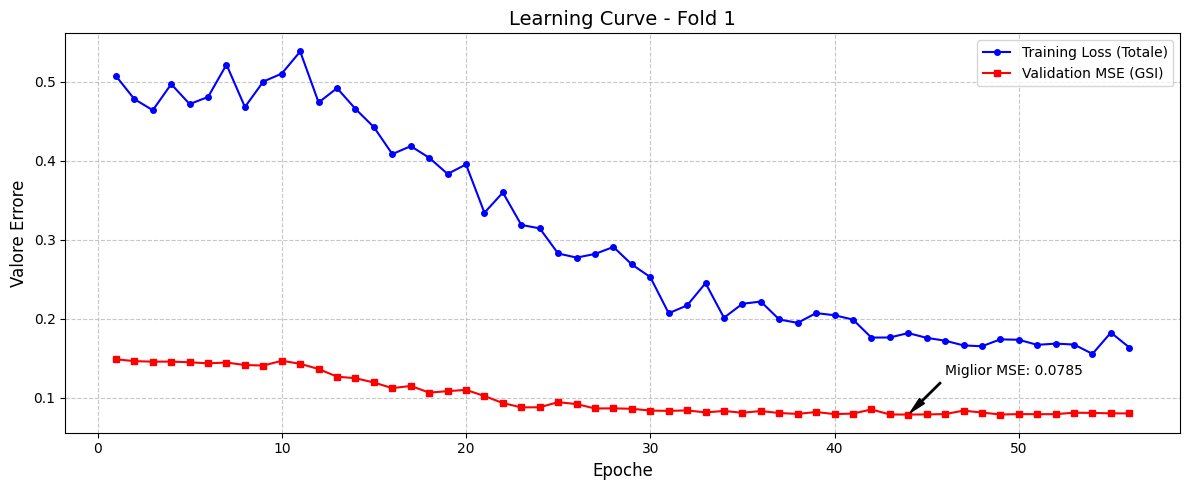


 INIZIO FOLD 2
Ep 02/60 | Train Loss: 0.5377 | Val MSE: 0.1761 Migliore
Ep 04/60 | Train Loss: 0.5240 | Val MSE: 0.1793 
Ep 06/60 | Train Loss: 0.5168 | Val MSE: 0.1848 
Ep 08/60 | Train Loss: 0.5050 | Val MSE: 0.1789 
Ep 10/60 | Train Loss: 0.5273 | Val MSE: 0.1777 
Ep 12/60 | Train Loss: 0.4707 | Val MSE: 0.1775 
Ep 14/60 | Train Loss: 0.5178 | Val MSE: 0.1770 
Early stopping all'epoca 14


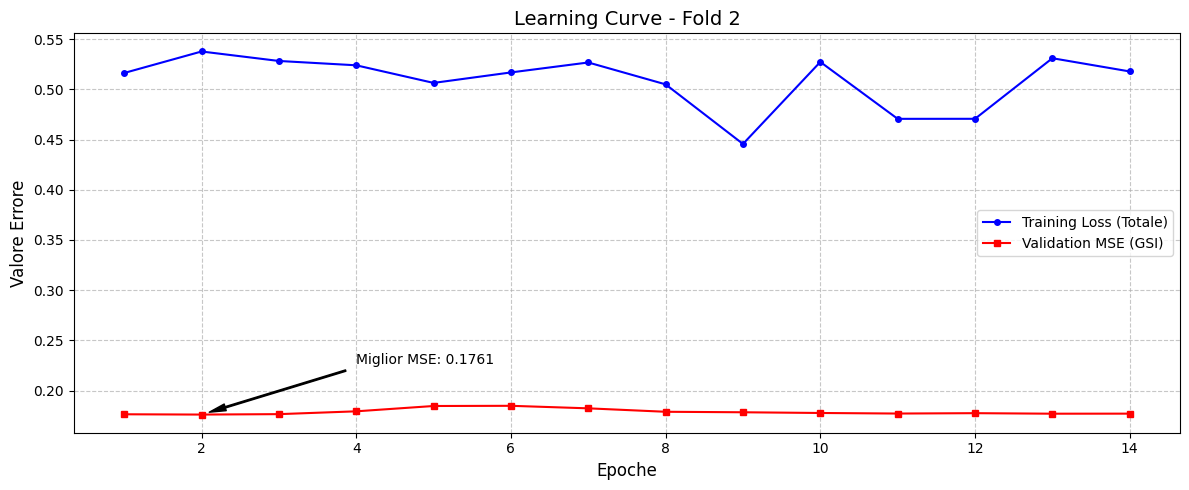


 INIZIO FOLD 3
Ep 02/60 | Train Loss: 0.5154 | Val MSE: 0.1710 Migliore
Ep 04/60 | Train Loss: 0.5188 | Val MSE: 0.1756 
Ep 06/60 | Train Loss: 0.5366 | Val MSE: 0.1670 Migliore
Ep 08/60 | Train Loss: 0.5383 | Val MSE: 0.1635 Migliore
Ep 10/60 | Train Loss: 0.5044 | Val MSE: 0.1533 Migliore
Ep 12/60 | Train Loss: 0.4764 | Val MSE: 0.1438 Migliore
Ep 14/60 | Train Loss: 0.4504 | Val MSE: 0.1299 Migliore
Ep 16/60 | Train Loss: 0.4309 | Val MSE: 0.1274 
Ep 18/60 | Train Loss: 0.3691 | Val MSE: 0.1018 Migliore
Ep 20/60 | Train Loss: 0.3781 | Val MSE: 0.0876 Migliore
Ep 22/60 | Train Loss: 0.3307 | Val MSE: 0.0816 Migliore
Ep 24/60 | Train Loss: 0.3173 | Val MSE: 0.0844 
Ep 26/60 | Train Loss: 0.2559 | Val MSE: 0.0791 
Ep 28/60 | Train Loss: 0.2644 | Val MSE: 0.0863 
Ep 30/60 | Train Loss: 0.2114 | Val MSE: 0.0568 Migliore
Ep 32/60 | Train Loss: 0.2263 | Val MSE: 0.0563 Migliore
Ep 34/60 | Train Loss: 0.1920 | Val MSE: 0.0479 Migliore
Ep 36/60 | Train Loss: 0.1694 | Val MSE: 0.0503 
Ep 38/

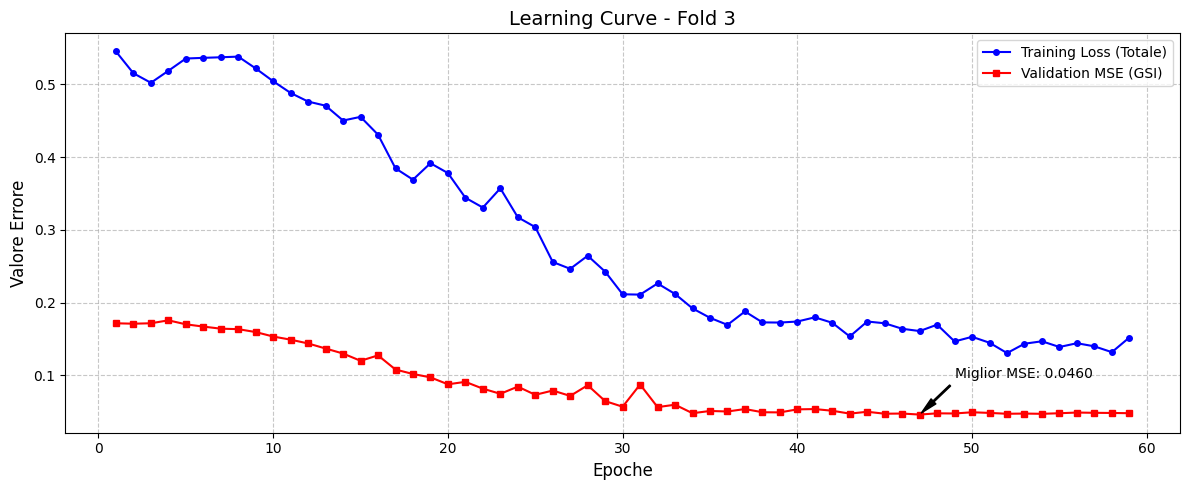


 INIZIO FOLD 4
Ep 02/60 | Train Loss: 0.5250 | Val MSE: 0.1829 Migliore
Ep 04/60 | Train Loss: 0.4692 | Val MSE: 0.1765 Migliore
Ep 06/60 | Train Loss: 0.5390 | Val MSE: 0.1727 Migliore
Ep 08/60 | Train Loss: 0.5040 | Val MSE: 0.1638 Migliore
Ep 10/60 | Train Loss: 0.4671 | Val MSE: 0.1656 
Ep 12/60 | Train Loss: 0.4850 | Val MSE: 0.1462 Migliore
Ep 14/60 | Train Loss: 0.4591 | Val MSE: 0.1286 Migliore
Ep 16/60 | Train Loss: 0.4014 | Val MSE: 0.1112 Migliore
Ep 18/60 | Train Loss: 0.3947 | Val MSE: 0.0948 Migliore
Ep 20/60 | Train Loss: 0.3309 | Val MSE: 0.0905 
Ep 22/60 | Train Loss: 0.3377 | Val MSE: 0.0758 
Ep 24/60 | Train Loss: 0.3235 | Val MSE: 0.0590 Migliore
Ep 26/60 | Train Loss: 0.2738 | Val MSE: 0.0525 Migliore
Ep 28/60 | Train Loss: 0.2533 | Val MSE: 0.0429 Migliore
Ep 30/60 | Train Loss: 0.2442 | Val MSE: 0.0404 Migliore
Ep 32/60 | Train Loss: 0.2126 | Val MSE: 0.0353 Migliore
Ep 34/60 | Train Loss: 0.1854 | Val MSE: 0.0316 Migliore
Ep 36/60 | Train Loss: 0.1883 | Val MSE

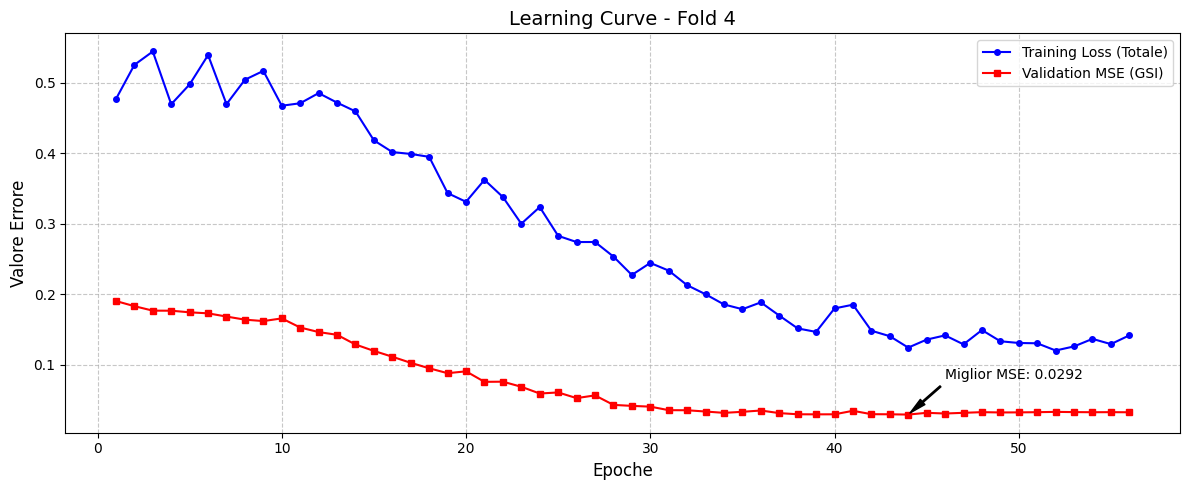


 INIZIO FOLD 5
Ep 02/60 | Train Loss: 0.5324 | Val MSE: 0.1597 Migliore
Ep 04/60 | Train Loss: 0.5483 | Val MSE: 0.1571 Migliore
Ep 06/60 | Train Loss: 0.5144 | Val MSE: 0.1550 Migliore
Ep 08/60 | Train Loss: 0.4930 | Val MSE: 0.1519 Migliore
Ep 10/60 | Train Loss: 0.4580 | Val MSE: 0.1485 Migliore
Ep 12/60 | Train Loss: 0.5006 | Val MSE: 0.1430 Migliore
Ep 14/60 | Train Loss: 0.4881 | Val MSE: 0.1304 Migliore
Ep 16/60 | Train Loss: 0.4970 | Val MSE: 0.1148 Migliore
Ep 18/60 | Train Loss: 0.3879 | Val MSE: 0.0984 Migliore
Ep 20/60 | Train Loss: 0.3967 | Val MSE: 0.0842 Migliore
Ep 22/60 | Train Loss: 0.3285 | Val MSE: 0.0719 Migliore
Ep 24/60 | Train Loss: 0.3186 | Val MSE: 0.0639 Migliore
Ep 26/60 | Train Loss: 0.2774 | Val MSE: 0.0691 
Ep 28/60 | Train Loss: 0.2806 | Val MSE: 0.0512 Migliore
Ep 30/60 | Train Loss: 0.2543 | Val MSE: 0.0476 Migliore
Ep 32/60 | Train Loss: 0.2211 | Val MSE: 0.0457 
Ep 34/60 | Train Loss: 0.1993 | Val MSE: 0.0475 
Ep 36/60 | Train Loss: 0.1922 | Val MSE

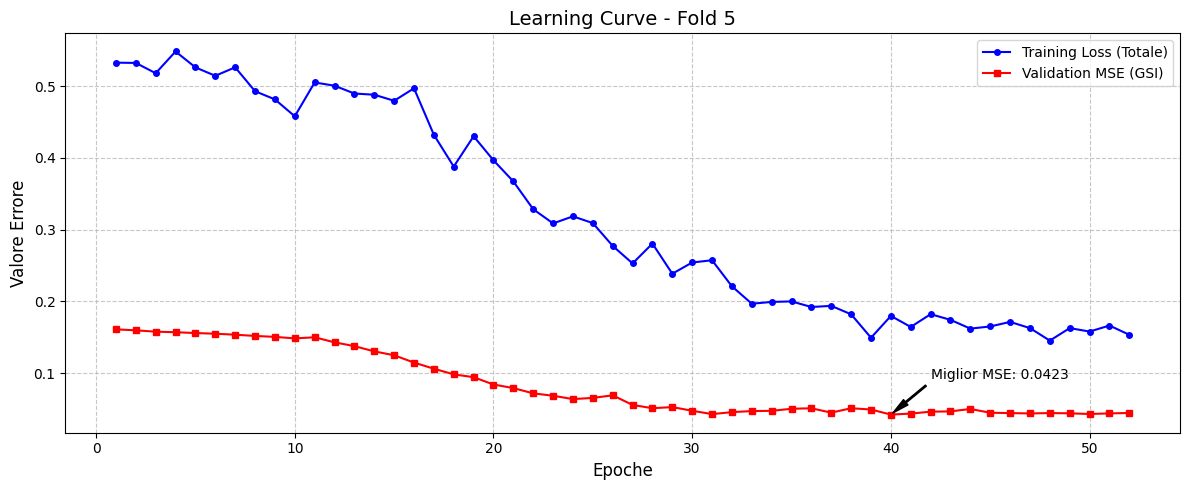


Addestramento Cross-Validation completato.


In [65]:
import matplotlib.pyplot as plt

def plot_learning_curves(history_train, history_val, fold_num):
    """
    Funzione per visualizzare l'andamento del training.
    """
    epochs = range(1, len(history_train) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Grafico unico per Loss e MSE
    plt.plot(epochs, history_train, 'b-o', label='Training Loss (Totale)', markersize=4)
    plt.plot(epochs, history_val, 'r-s', label='Validation MSE (GSI)', markersize=4)
    
    plt.title(f'Learning Curve - Fold {fold_num}', fontsize=14)
    plt.xlabel('Epoche', fontsize=12)
    plt.ylabel('Valore Errore', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Aggiungiamo una freccia sull'epoca migliore (quella con MSE minimo)
    best_epoch = history_val.index(min(history_val)) + 1
    best_val = min(history_val)
    plt.annotate(f'Miglior MSE: {best_val:.4f}', 
                 xy=(best_epoch, best_val), 
                 xytext=(best_epoch + 2, best_val + 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
    
    plt.tight_layout()
    plt.show()

def main():
    print(f"Caricamento Tokenizer ({CONFIG['model_name']})...")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
    tokenizer.truncation_side = 'left'

    # Dataset creato dal DataFrame pulito
    dataset = GSIDataset(df, tokenizer, CONFIG["max_len"])
    kfold = KFold(n_splits=CONFIG["n_splits"], shuffle=True, random_state=CONFIG["seed"])
    
    # Pesi per bilanciamento
    gs_values = dataset.data['gs_value'].astype(float).values
    sample_weights = [2.0 if (0.0 < v < 1.0) else 1.0 for v in gs_values]

    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
        print(f"\n" + "="*20)
        print(f" INIZIO FOLD {fold+1}")
        print("="*20)

        # Liste per memorizzare la storia del fold
        history_train_loss = []
        history_val_mse = []

        # Sampler e Loader
        train_fold_weights = [sample_weights[i] for i in train_ids]
        sampler = WeightedRandomSampler(train_fold_weights, len(train_fold_weights))
        
        train_loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], sampler=sampler)
        val_loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], sampler=SubsetRandomSampler(val_ids))

        # Inizializzazione Modello
        model = MultiTaskItalianBERT(CONFIG["model_name"]).to(device)

        # Ottimizzatore differenziato
        optimizer = AdamW([
            {'params': filter(lambda p: p.requires_grad, model.bert.parameters()), 'lr': 8e-6},
            {'params': model.reg_head.parameters(), 'lr': 5e-5},
            #{'params': model.aux_head.parameters(), 'lr': 5e-5}
        ], weight_decay=0.1)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        
        best_mse = float('inf')
        patience_counter = 0

        # LOOP EPOCHE
        for epoch in range(CONFIG["epochs"]):
            # Training
            t_loss, _ = train_epoch(model, train_loader, optimizer)
            # Validazione
            v_mse = eval_epoch(model, val_loader)

            # Salvataggio storia
            history_train_loss.append(t_loss)
            history_val_mse.append(v_mse)

            scheduler.step(v_mse)
            
            # Checkpoint miglior modello
            if v_mse < best_mse:
                best_mse = v_mse
                patience_counter = 0
                torch.save(model.state_dict(), f"best_fold_{fold+1}.pth")
                status = "Migliore"
            else:
                patience_counter += 1
                status = ""

            if (epoch+1) % 2 == 0: # Stampiamo ogni 2 epoche per monitorare meglio
                print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} | Train Loss: {t_loss:.4f} | Val MSE: {v_mse:.4f} {status}")
            
            # Early Stopping
            if patience_counter >= CONFIG['patience']: 
                print(f"Early stopping all'epoca {epoch+1}")
                break

        # A fine fold, stampa il grafico
        plot_learning_curves(history_train_loss, history_val_mse, fold+1)

        # Pulizia memoria per il prossimo fold
        del model, optimizer, train_loader, val_loader
        torch.cuda.empty_cache()

    print("\nAddestramento Cross-Validation completato.")

if __name__ == "__main__":
    main()


**VALUTAZIONE**
Data l’indisponibilità di un dataset ampio che permettesse di isolare un test set indipendente di dimensioni discrete, si è optato per una strategia di valutazione Out-of-Fold (OOF). Questa metodologia massimizza l'utilità dei 200 campioni disponibili, consentendo di testare il modello sull'intero dataset in modo statisticamente rigoroso.

La funzione final_cross_val_analysis aggrega le predizioni dei 5 fold per garantire una valutazione robusta attraverso tre fasi:

Quantitativa: Calcola l'accuratezza della regressione tramite metriche di errore (MSE/RMSE) e di allineamento (Correlazione di Pearson), verificando quanto la predizione di Umberto segua il trend del Gold Standard.

Diagnostica: Genera grafici di regressione e dei residui per identificare visivamente bias, scostamenti sistematici o problemi di calibrazione del modello.

Qualitativa: Isola i 5 errori più significativi per analizzare i limiti linguistici di Umberto (es. gestione di sarcasmo o ambiguità) rispetto al giudizio umano.

Caricamento Tokenizer e Dataset...
Inizio analisi aggregata con Umberto su 5 fold...
Fold 1 analizzato correttamente.
Fold 2 analizzato correttamente.
Fold 3 analizzato correttamente.
Fold 4 analizzato correttamente.
Fold 5 analizzato correttamente.

════════════════════════════════════════════════════════════
REPORT FINALE AGGREGATO (Strategia Out-of-Fold)
  MSE MODELLO:  0.0744
  MSE BASELINE: 0.1693 (Predizione della media)
  PERFORMANCE: Il modello supera la baseline del 56.04%
     Questo conferma un apprendimento reale dei pattern linguistici.
------------------------------------------------------------
  RMSE: 0.2728 | MAE: 0.1933
  Correlazione di Pearson: 0.7539
════════════════════════════════════════════════════════════


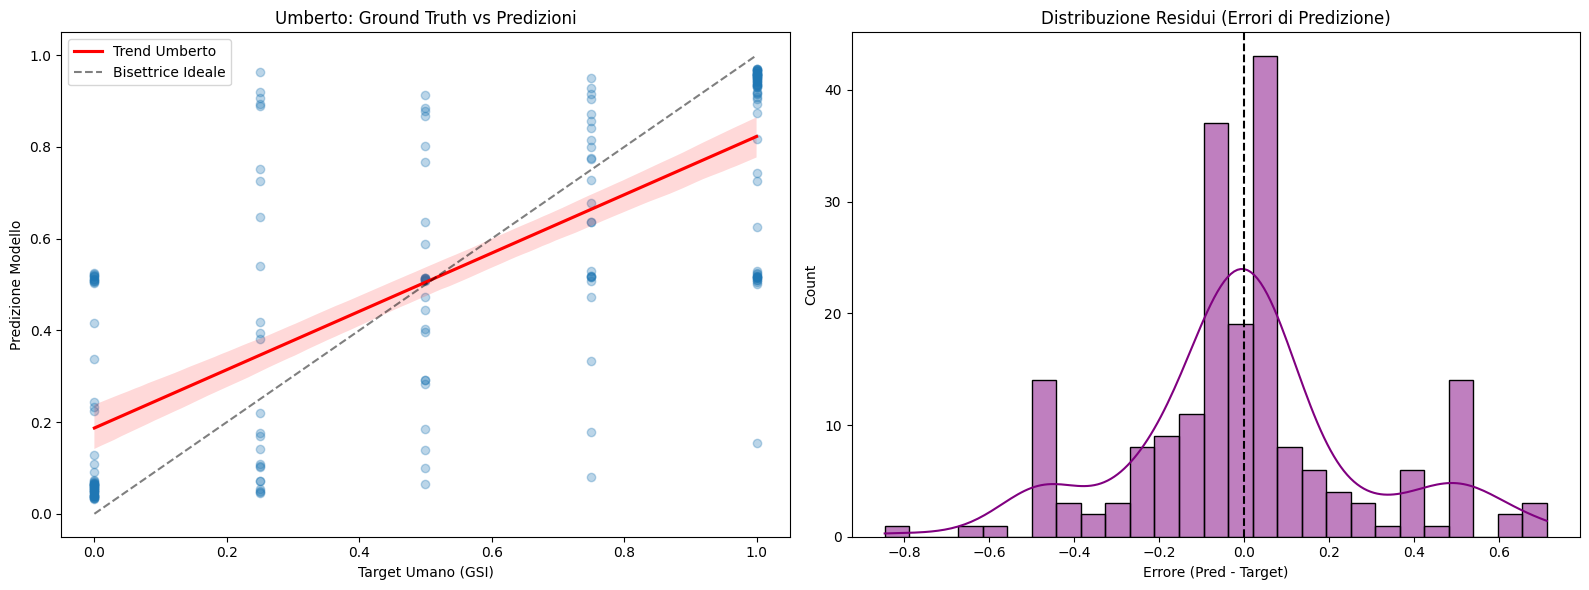


ANALISI ERRORI PEGGIORI (Possibile Over-reliance o Sarcasmo):
Errore: 0.847 | Reale: 1.00 | Pred: 0.15
Testo: Sono lavori da uomo e non si può giudicare solo dalla vostre descrizioni per fare notizia...
------------------------------
Errore: 0.713 | Reale: 0.25 | Pred: 0.96
Testo: Che palle avere le tette grandi e non sentirsi a proprio agio nel mettersi maglie nemmeno eccessivamente scollate...
------------------------------
Errore: 0.671 | Reale: 0.25 | Pred: 0.92
Testo: trovo abominevole che ci siano ancora donne che scelgono di partecipare a queste fiere espositive...
------------------------------
Errore: 0.670 | Reale: 0.75 | Pred: 0.08
Testo: Meno tatuaggi e pi coioni...
------------------------------
Errore: 0.657 | Reale: 0.25 | Pred: 0.91
Testo: Il quoziente intellettivo e le capacità sono uguali in entrambi i sessi...
------------------------------


In [75]:
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from transformers import AutoTokenizer

# 1. PREPARAZIONE AMBIENTE E DATASET
# Assicurati che 'df' (il tuo DataFrame pulito) sia disponibile in memoria
print(f"Caricamento Tokenizer e Dataset...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
tokenizer.truncation_side = 'left'

# Ricreiamo il dataset per assicurarci che sia definito correttamente nello scope
dataset = GSIDataset(df, tokenizer, CONFIG["max_len"])

def final_cross_val_analysis(dataset, tokenizer, n_splits=5):
    """
    Esegue l'analisi aggregata Out-of-Fold (OOF).
    Compara le performance del modello contro una baseline statistica.
    """
    # Usiamo lo stesso random state del training per testare sui validation set corretti
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=CONFIG["seed"])

    all_preds = []
    all_targets = []
    all_texts = []

    print(f"Inizio analisi aggregata con Umberto su {n_splits} fold...")

    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
        model_path = f"best_fold_{fold+1}.pth" 

        if not os.path.exists(model_path):
            print(f"Salto Fold {fold+1}: modello non trovato ({model_path})")
            continue

        # Inizializzazione e caricamento modello
        model = MultiTaskItalianBERT(CONFIG["model_name"]).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        with torch.no_grad():
            for i in val_ids:
                idx_standard = int(i)
                item = dataset[idx_standard]
                
                # Preparazione input
                ids = item['ids'].unsqueeze(0).to(device)
                mask = item['mask'].unsqueeze(0).to(device)
                tt_ids = item['token_type_ids'].unsqueeze(0).to(device)

                # Forward pass (reg_head fornisce il valore GSI)
                pred, _ = model(ids, mask, tt_ids) 

                all_preds.append(pred.item())
                all_targets.append(item['gs_target'].item())
                
                # Recupero testo originale
                testo_originale = dataset.data.iloc[idx_standard]['text']
                all_texts.append(testo_originale)

        print(f"Fold {fold+1} analizzato correttamente.")
        # Pulizia memoria GPU ad ogni fold
        del model
        torch.cuda.empty_cache()

    # Conversione in array per il calcolo delle metriche
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    if len(all_preds) == 0:
        print("Errore: Nessuna predizione raccolta. Verifica i file .pth")
        return

    # --- CALCOLO METRICHE E BASELINE ---
    # MSE del Modello
    mse_globale = np.mean((all_preds - all_targets)**2)
    
    # MSE di Baseline: cosa succederebbe se predicessimo sempre la media?
    target_mean = np.mean(all_targets)
    baseline_preds = np.full_like(all_targets, target_mean)
    mse_baseline = np.mean((baseline_preds - all_targets)**2)
    
    rmse_globale = np.sqrt(mse_globale)
    mae_globale = mean_absolute_error(all_targets, all_preds)
    corr, _ = pearsonr(all_preds, all_targets)

    # --- LOG DEI RISULTATI ---
    print("\n" + "═"*60)
    print(f"REPORT FINALE AGGREGATO (Strategia Out-of-Fold)")
    print(f"  MSE MODELLO:  {mse_globale:.4f}")
    print(f"  MSE BASELINE: {mse_baseline:.4f} (Predizione della media)")
    
    if mse_globale < mse_baseline:
        miglioramento = ((mse_baseline - mse_globale) / mse_baseline) * 100
        print(f"  PERFORMANCE: Il modello supera la baseline del {miglioramento:.2f}%")
        print(f"     Questo conferma un apprendimento reale dei pattern linguistici.")
    else:
        print(f" ATTENZIONE: Il modello non batte la baseline statistica.")
        
    print("-" * 60)
    print(f"  RMSE: {rmse_globale:.4f} | MAE: {mae_globale:.4f}")
    print(f"  Correlazione di Pearson: {corr:.4f}")
    print("═"*60)

    # --- VISUALIZZAZIONE ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Regression Plot: Ideale vs Reale
    sns.regplot(x=all_targets, y=all_preds, ax=ax1, scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'label':'Trend Umberto'})
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Bisettrice Ideale')
    ax1.set_title("Umberto: Ground Truth vs Predizioni")
    ax1.set_xlabel("Target Umano (GSI)")
    ax1.set_ylabel("Predizione Modello")
    ax1.legend()

    # Error Distribution: Distribuzione residui
    errors = all_preds - all_targets
    sns.histplot(errors, kde=True, ax=ax2, color='purple')
    ax2.axvline(0, color='black', linestyle='--')
    ax2.set_title("Distribuzione Residui (Errori di Predizione)")
    ax2.set_xlabel("Errore (Pred - Target)")
    
    plt.tight_layout()
    plt.show()

    # --- ANALISI ERRORI PEGGIORI (Qualitativa) ---
    abs_errors = np.abs(errors)
    indices_worst = np.argsort(abs_errors)[-5:] 
    
    print("\nANALISI ERRORI PEGGIORI (Possibile Over-reliance o Sarcasmo):")
    for idx in reversed(indices_worst):
        print(f"Errore: {abs_errors[idx]:.3f} | Reale: {all_targets[idx]:.2f} | Pred: {all_preds[idx]:.2f}")
        print(f"Testo: {all_texts[idx][:160]}...")
        print("-" * 30)

# ESECUZIONE FINALE
final_cross_val_analysis(dataset, tokenizer, n_splits=CONFIG["n_splits"])

**ANALISI RISULTATI**
Dall'analisi quantitativa emerge un dato fondamentale: il Mean Squared Error (MSE) del modello è significativamente inferiore al Baseline MSE (calcolato sulla predizione costante del valore medio del Gold Standard).

Questo confronto è cruciale per validare l'architettura scelta:

Superamento della Baseline: Se il modello avesse ottenuto un errore simile o superiore alla baseline, significherebbe che non è stato in grado di estrarre informazioni utili dal testo, limitandosi a "indovinare" il valore medio per minimizzare l'errore statistico.

Apprendimento Reale: Poiché il nostro MSE è più basso della baseline, abbiamo la conferma matematica che Umberto ha effettivamente appreso i pattern linguistici e le sfumature legate agli stereotipi. Il modello non sta semplicemente replicando la media dei voti umani, ma sta discriminando attivamente la gravità di ogni singola frase.